## Exercises from Chapter 6: Fine-tuning for classification

In [1]:
# Adding the repo root to sys.path
from pathlib import Path
import sys

# Current folder:
# repository_root/chapter_04/exercises
# i.e. 
# import os  
# print(os.getcwd()) # prints: c:\Users\delmi\Documents\LEARNING\Manning_Learning\repos\build-llm-from-scratch-pytorch\chapter_04\exercises 
# Note: Python searches for chapter_03 (and all other needed imports) inside that folder and in the other locations listed in sys.path. but sys.path currently does not have the repo root
# the snippet below adds the repo root to sys.path

repo_root = Path.cwd().parents[1]

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repository root:", repo_root)
sys.path

Repository root: c:\Users\delmi\Documents\LEARNING\Manning_Learning\repos\build-llm-from-scratch-pytorch


['c:\\Users\\delmi\\Documents\\LEARNING\\Manning_Learning\\repos\\build-llm-from-scratch-pytorch',
 'C:\\Users\\delmi\\anaconda3\\python312.zip',
 'C:\\Users\\delmi\\anaconda3\\DLLs',
 'C:\\Users\\delmi\\anaconda3\\Lib',
 'C:\\Users\\delmi\\anaconda3',
 'c:\\Users\\delmi\\venvs\\llmbookvenv',
 '',
 'c:\\Users\\delmi\\venvs\\llmbookvenv\\Lib\\site-packages']

### 6.2 Preparing the dataset


In [2]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "../data/sms_spam_collection.zip"
extracted_path = "../data/sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


def download_and_unzip_spam_data(
        url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download "
              "and extraction."
        )
        return

    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

..\data\sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [3]:
import pandas as pd

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [4]:
# Downsampling the majority class 'ham' class (because 'spam' class has way less samples)
def create_balanced_dataset(df):
    num_spam = df[df["Label"] == "spam"].shape[0]
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)

    balanced_df = pd.concat( [ham_subset, df[df["Label"] == "spam"]] ) # stacking them vertically
    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


In [5]:
balanced_df.head(3)

,Label,Text
4307,ham,Awww dat is sweet! We can think of something t...
4138,ham,Just got to &lt;#&gt;
4831,ham,"The word ""Checkmate"" in chess comes from the P..."


In [6]:
# Next, we convert the “string” class labels "ham" and "spam" into integer class labels 0 and 1, respectively:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})
balanced_df

,Label,Text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?
...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...


In [38]:
def random_split(df, train_frac, validation_frac):
    df = df.sample(frac = 1, random_state=123).reset_index(drop=True) # shuffling the df?
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

In [39]:
train_df["Label"].value_counts()

Label
0    528
1    517
Name: count, dtype: int64

In [40]:
train_df.to_csv("../data/train.csv", index=None)
validation_df.to_csv("../data/validation.csv", index=None)
test_df.to_csv("../data/test.csv", index=None)

### 6.3 Creating data loaders

In [41]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})

[50256]

In [50]:
import torch
from torch.utils.data import Dataset

# This ensures each input tensor is of the same size, which is necessary to create the batches in the training data loader we implement next
class SpamDataset(Dataset): # pads the shortest texts to have the same length as the longest (or truncates the texts to a preset max_length)
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256): # Note that max_length could be smaller than self._longest_encoded_length()
        self.data = pd.read_csv(csv_file) # this is a pandas DataFrame with columns: "Label" and "Text"
        self.encoded_texts = [tokenizer.encode(text) for text in self.data["Text"]]
        if max_length is None:
            self.max_length = self._longest_encoded_length() # the absolute max length of the encoded texts
        else:
            self.max_length = max_length # which is a set number which could be less than the real maximum length
            self.encoded_texts = [encoded_text[:self.max_length] for encoded_text in self.encoded_texts] # i.e possibly truncating encoded_texts to the preset max_length
        self.encoded_texts = [encoded_text + [pad_token_id]*(self.max_length-len(encoded_text)) for encoded_text in self.encoded_texts] # Padding 

    def __getitem__(self, index):
        encoded = self.encoded_texts[index] # gets the list of tokenIDs corresponding to the Text at row index
        label = self.data.iloc[index]["Label"] # is a string: either "ham" or "spam"
        return (torch.tensor(encoded, dtype=torch.long), torch.tensor(label, dtype=torch.long)) # Note: dtype=torch.long expects integer values

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if max_length < encoded_length:
                max_length = encoded_length
        return max_length

In [51]:
train_dataset = SpamDataset(
    csv_file="../data/train.csv",
    tokenizer=tokenizer,
    max_length=None
)

print(train_dataset.max_length)

120


In [52]:
val_dataset = SpamDataset(csv_file="../data/validation.csv", tokenizer=tokenizer, max_length=train_dataset.max_length)
val_dataset.max_length

120

In [53]:
test_dataset = SpamDataset(csv_file="../data/test.csv", tokenizer=tokenizer, max_length=train_dataset.max_length)
test_dataset.max_length

120

### Exercise 6.1 Increasing the context length
Pad the inputs to the maximum number of tokens the model supports and observe how it affects the predictive performance.

In [54]:
# The model's context_length limit is 1,024
gpt2_context_length_limit = 1024
train_dataset = SpamDataset(csv_file="../data/train.csv", tokenizer=tokenizer, max_length=gpt2_context_length_limit)
val_dataset = SpamDataset(csv_file="../data/validation.csv", tokenizer=tokenizer, max_length=gpt2_context_length_limit)
test_dataset = SpamDataset(csv_file="../data/test.csv", tokenizer=tokenizer, max_length=gpt2_context_length_limit)
print(train_dataset.max_length, val_dataset.max_length, test_dataset.max_length)

1024 1024 1024


In [55]:
# Back to using the max length of the encoded texts in the training dataset
train_dataset = SpamDataset(csv_file="../data/train.csv", tokenizer=tokenizer, max_length=None)
val_dataset = SpamDataset(csv_file="../data/validation.csv", tokenizer=tokenizer, max_length=train_dataset.max_length)
test_dataset = SpamDataset(csv_file="../data/test.csv", tokenizer=tokenizer, max_length=train_dataset.max_length)
print(train_dataset.max_length, val_dataset.max_length, test_dataset.max_length)

120 120 120


In [56]:
from torch.utils.data import DataLoader
torch.manual_seed(123)
batch_size = 8
num_workers = 0

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size = batch_size,
    shuffle= True,
    num_workers= num_workers,
    drop_last= True
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size = batch_size,
    num_workers= num_workers,
    drop_last= False
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size = batch_size,
    num_workers= num_workers,
    drop_last= False
)

for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions:", target_batch.shape)

Input batch dimensions: torch.Size([8, 120])
Label batch dimensions: torch.Size([8])


In [57]:
# Lastly, to get an idea of the dataset size, let’s print the total number of batches in each dataset:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


In [58]:
train = pd.read_csv("../data/train.csv")
tot_num_samples = len(train_df) + len(validation_df) + len(test_df)
tot_num_batches = len(train_loader) + len(val_loader) + len(test_loader)
print(f"Total number of samples in the dataset: {tot_num_samples}")
print(f"Total number of batches in the dataset: {tot_num_batches}")
print(f"Batch size: {batch_size}")
print(f"Total number of batches in the dataset x batch_size = {tot_num_batches} * {batch_size} = {tot_num_batches * batch_size}")

Total number of samples in the dataset: 1494
Total number of batches in the dataset: 187
Batch size: 8
Total number of batches in the dataset x batch_size = 187 * 8 = 1496


Keep in mind, the dataloaders cannot always find all batches that have 8 samples. Sometimes, the last batch has fewer samples (when the total number of samples is not  divisible by batch_size).

### 6.4 Initializing a model with pretrained weights

In [59]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"
BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [60]:
from chapter_05.scripts.gpt_download import download_and_load_gpt2
from chapter_05.scripts.training import load_weights_into_gpt
from chapter_04.scripts.gpt import GPTModel

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size, models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (drop_shortcut): Dropout(p=0.0, inplace=False)
      (norm2): LayerNorm()
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (att): MultiHeadAtten

In [61]:
from chapter_04.scripts.gpt import generate_text_simple
from chapter_05.scripts.generation import text_to_token_ids, token_ids_to_text

text_1 = "Every effort moves you"
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [62]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


### 6.5 Adding a classification head

In [63]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (drop_shortcut): Dropout(p=0.0, inplace=False)
      (norm2): LayerNorm()
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (att): MultiHeadAtten

In [64]:
# First we freeze the model (i.e. we make all the layers non trainable)
for param in model.parameters():
    param.requires_grad = False # we make ALL the layers non-trainable (we freeze the model)

In [65]:
# Then we replace the last linear output layer with a classification layer
torch.manual_seed(123)
num_classes = 2

model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"],
    out_features=num_classes
)

This new model.out_head output layer has its requires_grad attribute set to True by default, which means that it’s the only layer in the model that will be updated during training. Technically, training the output layer we just added is sufficient. However, as I found in experiments, fine-tuning additional layers can noticeably improve the predictive performance of the model. (For more details, refer to appendix B.) We also configure the last transformer block and the final LayerNorm module, which connects this block to the output layer, to be trainable

In [66]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

### Exercise 6.2 Fine-tuning the whole model
Instead of fine-tuning just the final transformer block, fine-tune the entire model and assess the effect on predictive performance.

In [67]:
for param in model.parameters():
    param.requires_grad = True

In [68]:
# RESET after Exercise 6.2: Now, in order to make the model in a way that follows the settings of the book, we refreeze all layers except for the:
# - out_head
# - the final layerNorm
# - the last TransformerBlock


for param in model.parameters():
    param.requires_grad = False

for param in model.out_head.parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

In [69]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


In [70]:
with torch.no_grad():
    outputs = model(inputs)
print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape)

Outputs:
 tensor([[[-1.5840,  0.9893],
         [-3.7231,  7.4521],
         [-2.2665,  6.6035],
         [-3.5974,  3.9888]]])
Outputs dimensions: torch.Size([1, 4, 2])


In [71]:
print(outputs[:, -1, :])

tensor([[-3.5974,  3.9888]])


### Exercise 6.3 Fine-tuning the first vs. last token
Try fine-tuning the first output token. Notice the changes in predictive performance compared to fine-tuning the last output token.

In [72]:
# We use:
model(input_batch)[:, 0, :] # instead of model(input_batch)[:, -1, :]

tensor([[-1.7716,  1.1662],
        [-1.4309,  1.2740],
        [-1.6606,  1.1312],
        [-1.6772,  1.2395],
        [-1.7236,  1.2882],
        [-1.6682,  1.1998],
        [-1.8687,  1.2912],
        [-1.7661,  1.1393]], grad_fn=<SelectBackward0>)

### 6.6 Calculating the classification loss and accuracy

In [73]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5974,  3.9888]])


In [74]:
logits = outputs[:, -1, :]
probas = torch.softmax(logits, dim=-1)
print(probas)
label = torch.argmax(probas, dim=-1, keepdim=True)
label.item()

tensor([[5.0717e-04, 9.9949e-01]])


1

In [75]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None): 
    model.eval() # disabling Dropout layers! (We will be doing inference below)
    correct_predictions, num_examples = 0, 0

    if num_batches is None: # i.e. if num_batches is NOT specified
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            with torch.no_grad():
                logits = model(input_batch)[:, -1, :] # doing inference! we only care about the last token!
            predicted_labels = torch.argmax(logits, dim=-1) # getting the index of the highest number - shape: (batch_size, seq_len)
            num_examples += predicted_labels.shape[0] # i.e. the batch_size 
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break

    return correct_predictions / num_examples # accuracy metric

In [76]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
torch.manual_seed(123)

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


In [78]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)[:, -1, :]
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

In [79]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [80]:
with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)
print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.455
Validation loss: 2.585
Test loss: 2.324


In [82]:
def train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs, eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()
            optimizer.step()
            examples_seen += input_batch.shape[0]
            global_step += 1


            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )


        train_accuracy = calc_accuracy_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_accuracy = calc_accuracy_loader(
            val_loader, model, device, num_batches=eval_iter
        )

        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

In [83]:
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5


train_losses, val_losses, train_accs, val_accs, examples_seen = \
    train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs=num_epochs, eval_freq=50,
        eval_iter=5
    )

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.155, Val loss 2.394
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.560, Val loss 0.488
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.396
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.334, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.344, Val loss 0.311
Training accuracy: 87.50% | Validation accuracy: 87.50%
Ep 4 (Step 000400): Train loss 0.180, Val loss 0.251
Ep 4 (Step 000450): Train loss 0.171, Val loss 0.150
Ep 4 (Step 000500): Train loss 0.228, Val loss 0.150
Training accuracy: 100.00% | Validation accuracy: 95.00%
Ep 5 (Step 000550): Train loss 0.208, Val loss 0.153
Ep 5 (Step 000600): Train loss 0.093, Val loss 0.079
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 16.52 m

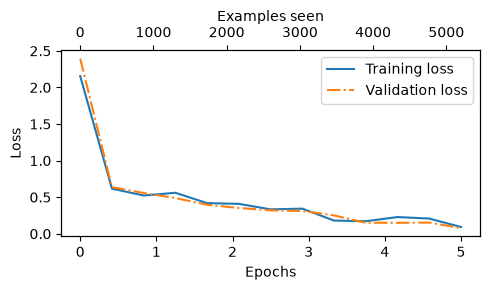

In [84]:
import matplotlib.pyplot as plt

def plot_values(
        epochs_seen, examples_seen, train_values, val_values,
        label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))


    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(
        epochs_seen, val_values, linestyle="-.",
        label=f"Validation {label}"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()


    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

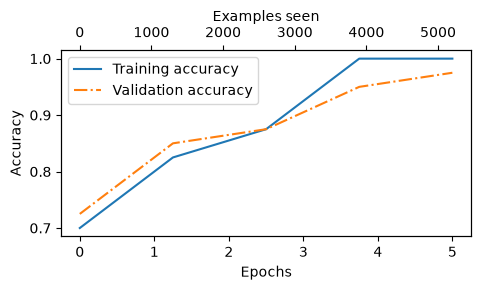

In [85]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(
    epochs_tensor, examples_seen_tensor, train_accs, val_accs,
    label="accuracy"
)

In [86]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 96.83%
Validation accuracy: 97.32%
Test accuracy: 95.67%


### 6.8 Using the LLM as a spam classifier

In [87]:
def classify_review(
        text, model, tokenizer, device, max_length=None,
        pad_token_id=50256):
    model.eval()

    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]

    input_ids = input_ids[:min(
        max_length, supported_context_length
    )]

    input_ids += [pad_token_id] * (max_length - len(input_ids))

    input_tensor = torch.tensor(
        input_ids, device=device
    ).unsqueeze(0)

    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
    predicted_label = torch.argmax(logits, dim=-1).item()

    return "spam" if predicted_label == 1 else "not spam"

In [100]:
text_1 = ("URGENT!!! ACT NOW!"
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [ ]:
text_2 = (
    "Hey! just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


In [92]:
text_3 = (
    "URGENT!!! ACT NOW!!!!You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_3, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [ ]:
# SAVING THE MODEL
torch.save(model.state_dict(), "../data/review_classifier.pth")

In [104]:
# LOADING THE MODEL
# Once saved, the model can be loaded:
model_state_dict = torch.load("../data/review_classifier.pth", map_location=device)
model.load_state_dict(model_state_dict)

<All keys matched successfully>